# Определимость эффективной толщины верхнего слоя по данным боковых тетраполярных измерений

**Объект расчёта:** боковые тетраполярные электродные сборки эксперимента 2.

**Исходный материал:** 19 отдельных последовательных записей двух добровольцев —
10 записей Георга и 9 записей Ника.

**Тип работы:** вычислительный эксперимент с плоской двуслойной моделью.

**Статус результата:** результат математического моделирования в рамках разработки
методики. Анатомическая, метрологическая и экспериментальная валидация не
выполнены.

## Основной результат и область его применимости

В принятой модели эффективная толщина верхнего слоя $h$ не определяется как
самостоятельный параметр по имеющейся размерной зависимости. Для обоих
добровольцев наименьшее среднеквадратичное расхождение модели и наблюдений
получено в нижнем узле расчётной сетки, $h=1$ мм. Внутренний минимум в
диапазоне 1–80 мм отсутствует, а изменения $h$ почти полностью компенсируются
изменениями удельного сопротивления верхнего слоя $\rho_1$ и остальных
параметров модели.

Значение $h=1$ мм является положением минимума на заданной вычислительной
сетке, а не оценкой анатомической толщины. Результат относится одновременно к
выбранной прямой модели, номинальной геометрии электродов, принятой приборной
шкале и допущению о сопоставимости последовательных записей. Он не доказывает,
что электрические измерения в принципе не содержат информации о глубине, но
показывает, что в данной постановке эта информация не отделяется от влияния
$\rho_1$, геометрии и неучтённых различий между записями.


## 1. Цель и критерии расчёта

Цель вычислительного эксперимента — проверить практическую определимость
эффективной толщины верхнего слоя $h$ по зависимости бокового передаточного
импеданса от размера электродной сборки.

В настоящем ноутбуке параметр $h$ считается практически определимым, если
одновременно выполняются следующие условия:

1. профиль целевой функции имеет внутренний минимум по $h$, а не минимум на
   границе заданной сетки;
2. положение минимума устойчиво к допустимым изменениям остальных параметров;
3. подобранные удельные сопротивления не достигают технических границ
   оптимизации;
4. изменения $h$ нельзя с достаточной точностью воспроизвести изменениями
   $\rho_1$, $\rho_2$, геометрии электродов или постоянного смещения;
5. результат допускает последующую проверку на данных, не использованных при
   подборе параметров.

Заранее заданных порогов для кривизны профиля, устойчивости минимума и числа
обусловленности пока нет. Поэтому расчёт выявляет структуру обратной задачи и
практическую неразделимость параметров, но не даёт доверительный интервал для
$h$ и не оценивает точность конечной методики.


## 2. Исходные данные и расчётные наблюдения

В эксперименте 2 использовался реокардиомонитор МГТУ. Канал 2 регистрировал
сигнал боковой электродной сборки. Для Георга отобраны десять отдельных
записей с размерами сборки от 50 до 140 мм. Для Ника используются девять
отдельных записей в том же диапазоне; поздняя запись, обозначенная как 100 мм,
исключена как копия записи 90 мм.

Сборки разных размеров регистрировались последовательно, а не одновременно.
Их объединение в одну размерную зависимость основано на допущении о
сопоставимости физиологического состояния, положения электродов и качества
контакта между записями. Это допущение необходимо для текущего расчёта и не
считается подтверждённым свойством данных.

Для каждого размера рассматриваются два дыхательных состояния:

- задержка дыхания после вдоха;
- задержка дыхания после выдоха.

Метки команд дыхательного протокола прибором не регистрировались. Границы
интервалов восстановлены ретроспективно по памяти и форме сигналов и пока
имеют статус кандидатной разметки. В каждом интервале исключается по 0,5 с с
обоих краёв, после чего вычисляется медиана `BASE_2_Ω`. Эта медиана образует
одну агрегированную точку для заданных размера сборки и дыхательного состояния.

Канал `RHEO_2_mΩ` используется отдельно для расчёта усреднённых пульсовых
кривых. Этот вспомогательный модельный расчёт не участвует в выборе $h$ и не
изменяет основной вывод о статической определимости толщины.

## 3. Прямая модель

Исследуемая область представлена плоским двуслойным полупространством:

- верхний слой — мягкие ткани грудной стенки с удельным сопротивлением
  $\rho_1$ и эффективной толщиной $h$;
- нижний полубесконечный слой — лёгкое с удельным сопротивлением $\rho_2$.

Электроды считаются точечными и расположенными на одной прямой. Расстояние
между токовыми электродами равно $L=2a$. Измерительные электроды расположены
симметрично, причём $b/a=0{,}5$.

Передаточный импеданс рассчитывается по выражению

$$
Z=\frac{\rho_1}{\pi}\left(\frac{1}{a-b}-\frac{1}{a+b}\right)
+\frac{2\rho_1}{\pi}\sum_{n=1}^{\infty}q^n
\left[
\frac{1}{\sqrt{(a-b)^2+(2nh)^2}}
-\frac{1}{\sqrt{(a+b)^2+(2nh)^2}}
\right],
$$

где $Z$ — передаточный импеданс, Ом; $a$ и $b$ — геометрические параметры
сборки, м; $h$ — эффективная толщина верхнего слоя, м; $n$ — номер члена ряда;
$\rho_1$ и $\rho_2$ — удельные сопротивления верхнего и нижнего слоёв, Ом·м;
коэффициент отражения $q$ определяется выражением

$$
q=\frac{\rho_2-\rho_1}{\rho_1+\rho_2},
$$

где $q$ — безразмерный коэффициент отражения; $\rho_1$ и $\rho_2$ —
удельные сопротивления верхнего и нижнего слоёв соответственно, Ом·м.

Для вдоха и выдоха принимаются общие $h$ и $\rho_1$, но отдельные значения
$\rho_{2,\mathrm{in}}$ и $\rho_{2,\mathrm{ex}}$. Следовательно, статическая
модель приписывает всё различие между двумя дыхательными состояниями изменению
эффективного удельного сопротивления нижнего слоя. Это допущение модели, а не
установленный физиологический механизм.

Параметр $h$ является эффективным параметром редуцированной модели. Он может
компенсировать кривизну поверхности, неоднородность кожи, жировой ткани и мышц,
влияние рёбер, конечную площадь электродов и другие отличия реальной анатомии
от плоского полупространства. Поэтому расчётное значение $h$ нельзя
непосредственно отождествлять с анатомической толщиной мягких тканей.

## 4. Сценарий приборной шкалы и допущения

В текущем вычислительном сценарии принято

$$
Z_{\mathrm{obs}}=\mathrm{BASE\_2},
\qquad
\Delta Z(t)=0{,}001\,\mathrm{RHEO\_2}(t),
$$

где $Z_{\mathrm{obs}}$ — наблюдаемый знаковый передаточный импеданс, Ом, а
$\Delta Z(t)$ — пульсовое приращение импеданса, Ом.

Таким образом, отображение `BASE_2_Ω` в передаточный импеданс с коэффициентом
масштаба 1, нулевым смещением и положительным знаком является явным допущением
сценария. `RHEO_2_mΩ` переводится из миллиомов в омы и также используется с
коэффициентом 1 и положительным знаком. Отдельная электрическая или фантомная
проверка этого отображения в настоящем ноутбуке не выполняется.

| Элемент постановки | Принято в расчёте | Ограничение интерпретации |
|---|---|---|
| Анатомия | Плоское двуслойное полупространство | Кривизна, рёбра и неоднородность тканей не разделены |
| Мягкие ткани | Один однородный слой с общим $\rho_1$ | Кожа, жир и мышцы не оцениваются раздельно |
| Дыхание | Общие $h$ и $\rho_1$ на вдохе и выдохе | Всё статическое различие приписывается $\rho_2$ нижнего слоя |
| Электроды | Точечные электроды; $L=2a$; $b/a=0{,}5$ | Площадь, контакт и ошибка ручной установки не входят в модель |
| Последовательность | Записи разных размеров сопоставимы | Влияние времени и повторной установки смешано с влиянием размера |
| Наблюдение | Медиана `BASE_2_Ω` на кандидатном интервале | Наклон и внутринтервальная изменчивость не моделируются |
| Приборная шкала | Масштаб 1, смещение 0, знак +1 | Это допущение вычислительного сценария |
| Целевая функция | Невзвешенная сумма квадратов остатков | Разная неопределённость записей и размеров не учитывается |
| Диапазоны | $h=1\ldots80$ мм; $\rho=0{,}01\ldots1000$ Ом·м | Границы являются вычислительными, а не анатомическими |

Источники расхождения модели и данных не объединяются словом «шум», поскольку
их происхождение, диапазоны и вероятностные распределения пока не установлены.


## 5. Подготовка данных и контроль происхождения

Для каждой записи выполняются следующие операции:

1. загружаются кандидатные интервалы дыхательных режимов и кандидатные
   R-зубцы ЭКГ;
2. по контрольным суммам проверяется соответствие разметки исходному CSV;
3. проверяется наличие времени, основного уровня канала 2 и реографической
   составляющей канала 2;
4. для задержек после вдоха и выдоха вычисляются медианы `BASE_2_Ω`;
5. отдельно формируются пульсовые ансамбли `RHEO_2_mΩ`.

В расчёт должны войти ровно 19 отобранных записей. Несовпадение числа записей,
контрольных сумм или набора обязательных столбцов останавливает выполнение.
Такой контроль обеспечивает прослеживаемость расчётных точек, но не заменяет
ручную проверку дыхательной и ЭКГ-разметки.


In [1]:
# Загрузка конфигурации и функций
import hashlib
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from exploratory_analysis import (
    EXPLORATORY_STATUS,
    dynamic_two_layer_inverse,
    interval_median,
    normalized_modes,
    profile_static_h,
    pulse_ensemble,
    select_rpeaks,
)

CONFIG_ENV = "KALMYKOV_EXP02_CONFIG"
config_value = os.environ.get(CONFIG_ENV)
if not config_value:
    raise RuntimeError(f"Задайте {CONFIG_ENV} до запуска")
CONFIG_PATH = Path(config_value).expanduser().resolve()
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
DATA_ROOT = Path(CONFIG["data_root"]).expanduser().resolve()
DERIVED_ROOT = Path(CONFIG["derived_root"]).expanduser().resolve()
BREATHING_DIR = DERIVED_ROOT / "exp02" / "annotations" / "breathing"
ECG_DIR = DERIVED_ROOT / "exp02" / "annotations" / "ecg"
OUT_DIR = DERIVED_ROOT / "exp02" / "exploratory"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "33.06_side_arrays_exploratory.json"

H_GRID_M = np.arange(0.001, 0.080 + 0.0001, 0.001)
HOLD_MODES = {
    "задержка_вдох": "inhale",
    "задержка_выдох": "exhale",
}


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def json_ready(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: json_ready(child) for key, child in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(child) for child in value]
    return value


def resolve_input(relative_path):
    path = (DATA_ROOT / relative_path).resolve()
    path.relative_to(DATA_ROOT)
    if not path.is_file():
        raise FileNotFoundError(relative_path)
    return path


In [2]:
# Загрузка 19 отобранных записей и вычисление наблюдаемых уровней
records_by_subject = {}
input_provenance = []
for breathing_path in sorted(BREATHING_DIR.glob("*.json")):
    breathing = json.loads(breathing_path.read_text(encoding="utf-8"))
    if breathing.get("annotation_type") != "breathing":
        continue
    record_id = breathing["record_id"]
    ecg_path = ECG_DIR / f"{record_id}.json"
    if not ecg_path.is_file():
        raise RuntimeError(f"Нет ЭКГ-sidecar для {record_id}; сначала запустите 11.02")
    ecg = json.loads(ecg_path.read_text(encoding="utf-8"))
    source_path = resolve_input(breathing["input"]["relative_path"])
    source_sha256 = sha256_file(source_path)
    if source_sha256 != breathing["input"]["sha256"] or source_sha256 != ecg["input"]["sha256"]:
        raise RuntimeError(f"Конфликт SHA-256 для {record_id}")

    frame = pd.read_csv(source_path, encoding="utf-8")
    required = {"TIME_s", "BASE_2_Ω", "RHEO_2_mΩ"}
    if not required.issubset(frame.columns):
        raise ValueError(f"В {record_id} отсутствуют столбцы {sorted(required - set(frame.columns))}")
    time_s = frame["TIME_s"].to_numpy(dtype=float)
    base_2_ohm = frame["BASE_2_Ω"].to_numpy(dtype=float)
    rheo_2_mohm = frame["RHEO_2_mΩ"].to_numpy(dtype=float)
    modes, mode_selection = normalized_modes(breathing)
    rpeaks = select_rpeaks(ecg, prefer_diagnostic=False)
    for name in HOLD_MODES:
        if name not in modes:
            raise RuntimeError(f"В {record_id} нет кандидатного режима {name}")

    record = {
        "record_id": record_id,
        "subject_id": breathing["subject_id"],
        "size_mm": int(breathing["size_mm"]),
        "time_s": time_s,
        "base_2_ohm": base_2_ohm,
        "rheo_2_mohm": rheo_2_mohm,
        "modes": modes,
        "rpeaks_s": rpeaks.values,
        "z_inhale_ohm": interval_median(time_s, base_2_ohm, modes["задержка_вдох"]),
        "z_exhale_ohm": interval_median(time_s, base_2_ohm, modes["задержка_выдох"]),
    }
    records_by_subject.setdefault(record["subject_id"], []).append(record)
    input_provenance.append({
        "record_id": record_id,
        "subject_id": record["subject_id"],
        "size_mm": record["size_mm"],
        "source_csv_sha256": source_sha256,
        "breathing_sidecar_sha256": sha256_file(breathing_path),
        "breathing_qc_status": mode_selection.qc_status,
        "breathing_field": mode_selection.source_field,
        "ecg_sidecar_sha256": sha256_file(ecg_path),
        "ecg_qc_status": rpeaks.qc_status,
        "ecg_field": rpeaks.source_field,
    })

expected_count = int(CONFIG["expected_independent_record_count"])
if len(input_provenance) != expected_count:
    raise RuntimeError(f"Загружено {len(input_provenance)} записей вместо {expected_count}")


## 6. Профилирование эффективной толщины

Для каждого добровольца формируется размерная зависимость из медиан
`BASE_2_Ω` для двух дыхательных состояний. Для наблюдения, соответствующего
размеру $i$ и состоянию $s$, остаток определяется как

$$
r_{i,s}=Z^{\mathrm{mod}}_{i,s}-Z^{\mathrm{obs}}_{i,s},
$$

где $r_{i,s}$ — остаток для размера с индексом $i$ и дыхательного состояния
$s$, Ом; $Z^{\mathrm{mod}}_{i,s}$ и $Z^{\mathrm{obs}}_{i,s}$ — рассчитанный
и наблюдаемый импедансы соответственно, Ом. Положительный остаток означает, что
модель завышает наблюдаемое значение; отрицательный — что занижает его.

На сетке $h=1,2,\ldots,80$ мм для каждого фиксированного $h$ методом наименьших
квадратов заново подбираются три положительных параметра: общее для двух
дыхательных состояний $\rho_1$, а также отдельные
$\rho_{2,\mathrm{in}}$ и $\rho_{2,\mathrm{ex}}$.

Целевая функция и среднеквадратичное расхождение имеют вид

$$
E(h)=\sum_{i,s}r_{i,s}^2,
\qquad
\operatorname{RMS}(h)=\sqrt{\frac{E(h)}{N}},
$$

где $E(h)$ — сумма квадратов остатков при заданном $h$, Ом²;
$\operatorname{RMS}(h)$ — среднеквадратичное расхождение, Ом; $N$ — общее
число агрегированных точек двух дыхательных состояний. Профиль
целевой функции определяется как

$$
P(h)=\min_{\rho_1,\rho_{2,\mathrm{in}},\rho_{2,\mathrm{ex}}}E(h),
$$

где $P(h)$ — наименьшая сумма квадратов, которую можно получить при заданном
$h$ после подбора трёх удельных сопротивлений. Для каждого узла сетки сохраняются подобранные удельные сопротивления, RMS,
число обусловленности и признаки достижения технических границ параметров.
Узел с наименьшим $P(h)$ является только кандидатом на оценку $h$: для
интерпретации необходимы внутренний минимум, достаточная кривизна профиля и
различимость влияния параметров.

### 6.1. Вспомогательное восстановление пульсовых приращений

Вспомогательный пульсовой расчёт является чисто модельной операцией. После
статической подгонки модель линеаризуется в выбранной рабочей точке:

$$
\Delta Z_i(t)\approx
J_{i1}\,\Delta\rho_1(t)+J_{i2}\,\Delta\rho_2(t),
$$

где $\Delta Z_i(t)$ — пульсовое приращение импеданса сборки $i$ в момент
времени $t$, Ом; $\Delta\rho_1(t)$ и $\Delta\rho_2(t)$ — искомые
приращения удельных сопротивлений слоёв, Ом·м; $J_{i1}$ и $J_{i2}$ —
производные передаточного импеданса по этим сопротивлениям для сборки размера
$i$. В каждый момент времени система
по всем размерам решается методом наименьших квадратов относительно
$\Delta\rho_1(t)$ и $\Delta\rho_2(t)$.

Полученные кривые условны относительно статической рабочей точки, линейности
оператора и сопоставимости пульсовых ансамблей из последовательных записей.
Это не статистическое оценивание, не независимое измерение тканевых параметров
и не дополнительное уравнение для статической оценки $h$.


In [3]:
# Профиль h, статическая подгонка и линейный пульсовой расчёт
subject_results = {}
for subject_id, records in sorted(records_by_subject.items()):
    records = sorted(records, key=lambda item: item["size_mm"])
    sizes_mm = np.asarray([item["size_mm"] for item in records], dtype=float)
    z_inhale = np.asarray([item["z_inhale_ohm"] for item in records])
    z_exhale = np.asarray([item["z_exhale_ohm"] for item in records])
    static_profile = profile_static_h(
        sizes_mm / 1000.0,
        z_inhale,
        z_exhale,
        H_GRID_M,
    )
    best_static = static_profile["best"]
    dynamic = {}
    for mode_name, state in HOLD_MODES.items():
        waveforms = []
        ensembles = []
        common_grid = None
        for record in records:
            ensemble = pulse_ensemble(
                record["time_s"],
                record["rheo_2_mohm"],
                record["rpeaks_s"],
                record["modes"][mode_name],
                CONFIG["pulse_analysis"],
                sign=1.0,
                gain=1.0,
            )
            if common_grid is None:
                common_grid = ensemble["grid_s"]
            elif not np.array_equal(common_grid, ensemble["grid_s"]):
                raise RuntimeError("Временные сетки ансамблей не совпадают")
            waveforms.append(ensemble["mean"])
            ensembles.append({
                "record_id": record["record_id"],
                "size_mm": record["size_mm"],
                "n_beats": ensemble["n_beats"],
                "n_rejected": ensemble["n_rejected"],
                "mean_ohm": ensemble["mean"],
                "se_within_record_ohm": ensemble["se_within_record"],
            })
        inverse = dynamic_two_layer_inverse(
            sizes_mm / 1000.0,
            np.asarray(waveforms),
            best_static,
            state,
        )
        dynamic[mode_name] = {
            "state": state,
            "grid_s": common_grid,
            "ensembles": ensembles,
            **inverse,
        }

    subject_results[subject_id] = {
        "sizes_mm": sizes_mm,
        "observed_z_inhale_ohm": z_inhale,
        "observed_z_exhale_ohm": z_exhale,
        "static_h_profile": static_profile,
        "dynamic": dynamic,
    }


### 6.2. Как строится и читается профиль ошибки

Профиль ошибки — производная расчётная кривая, а не исходный сигнал и не
изменение толщины во времени. Одна точка профиля строится следующим образом:

1. выбирается одно кандидатное значение $h$;
2. это значение временно фиксируется;
3. по всем размерам сборок заново подбираются $\rho_1$,
   $\rho_{2,\mathrm{in}}$ и $\rho_{2,\mathrm{ex}}$;
4. после подбора вычисляется минимально достижимый RMS.

Затем операция повторяется для следующего $h$. Поэтому соседние точки кривой
соответствуют разным полным наборам параметров. На рисунке по горизонтали
отложено проверяемое $h$, а по вертикали — наименьший RMS, который модель
может получить при этом $h$. График RMS имеет те же минимумы, что и $P(h)$,
но выражен в омах и поэтому проще интерпретируется.

Изолированный внутренний минимум, окружённый заметно большими значениями RMS,
означал бы, что одно значение $h$ предпочтительнее соседних в пределах
принятого критерия. Пологий участок означает, что широкий диапазон $h$ даёт
почти одинаковое качество подгонки. Минимум в крайней точке сетки означает,
что кривая не образовала замкнутой впадины внутри исследованного диапазона;
крайний узел в таком случае нельзя считать измеренной толщиной. Малый RMS сам
по себе также не подтверждает физическую правильность модели.


Расчётные данные сохранены во внешнем каталоге производных результатов.


,Доброволец,Число размеров,"h минимума сетки, мм","RMS статической подгонки, Ом",Число обусловленности статической задачи,"Число обусловленности линейного пульсового оператора, вдох","Число обусловленности линейного пульсового оператора, выдох"
0,Георг,10,1.0,7.6743,6.1373,80.8742,71.8779
1,Ник,9,1.0,6.1028,5.8746,72.6154,59.4810


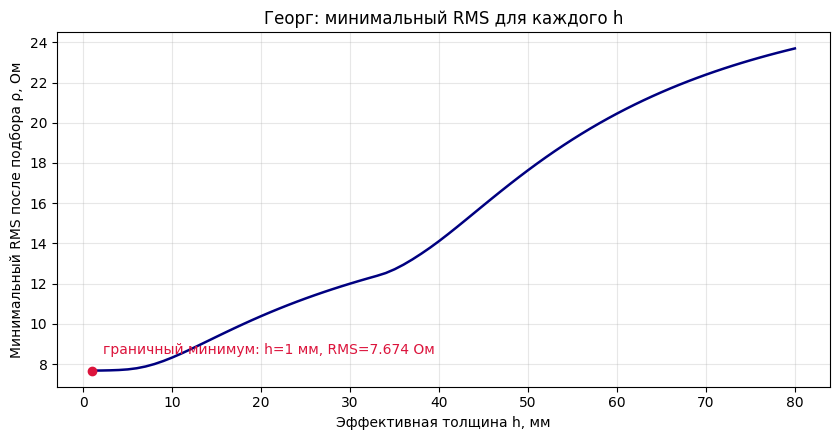

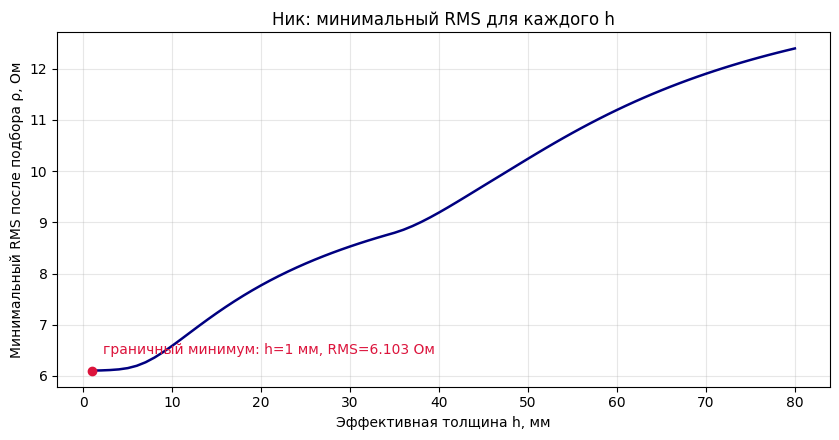

In [4]:
# Сохранение отдельного исследовательского артефакта
artifact = {
    "schema_version": 1,
    "status": EXPLORATORY_STATUS,
    "artifact_id": "33.06_side_arrays_exploratory",
    "experiment_id": "exp02",
    "strict_pipeline_authorized": False,
    "configuration_sha256": sha256_file(CONFIG_PATH),
    "input_provenance": input_provenance,
    "scenario": {
        "static_observation": "BASE_2_Ω_as_signed_transfer_impedance_ohm",
        "static_gain": 1.0,
        "static_offset_ohm": 0.0,
        "static_sign": 1,
        "pulse_unit_scale_to_ohm": float(CONFIG["pulse_analysis"]["unit_scale_to_ohm"]),
        "pulse_gain": 1.0,
        "pulse_sign": 1,
        "h_grid_mm": (H_GRID_M * 1000.0).tolist(),
        "h_grid_interpretation": "computational_sweep_not_anatomical_prior",
    },
    "assumptions": [
        "candidate_breathing_intervals_are_usable_for_exploratory_calculation",
        "candidate_rpeaks_are_usable_for_exploratory_ensembles",
        "sequential_size_recordings_represent_comparable_physiological_states",
        "two_layer_flat_halfspace_is_an_adequate_first_model",
        "h_is_constant_between_inhale_and_exhale_in_each_profile_row",
        "rho1_is_constant_between_inhale_and_exhale",
        "linearized_dynamic_model_is_adequate",
        "unknown_instrument_scale_is_temporarily_gain_1_offset_0_sign_plus",
    ],
    "limitations": [
        "all_breathing_and_ecg_annotations_remain_pending_manual_review",
        "individual_h_is_not_supplied_from_ct",
        "BASE_2_and_RHEO_2_are_not_calibrated",
        "no_distribution_is_assigned_to_combined_error_sources",
        "no_ct_fem_validation_of_the_flat_two_layer_operator",
        "dynamic_sign_reverses_if_the_instrument_sign_scenario_is_reversed",
    ],
    "subjects": subject_results,
}
OUT_PATH.write_text(
    json.dumps(json_ready(artifact), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

display_names = {
    "exp02_georg": "Георг",
    "exp02_nik": "Ник",
}

summary = {
    display_names.get(subject_id, subject_id): {
        "n_sizes": len(result["sizes_mm"]),
        "best_h_mm_on_computational_grid": result["static_h_profile"]["best"]["h_m"] * 1000.0,
        "static_residual_rms_ohm": result["static_h_profile"]["best"]["residual_rms_ohm"],
        "static_condition": result["static_h_profile"]["best"]["jacobian_log_condition"],
        "dynamic_condition_inhale": result["dynamic"]["задержка_вдох"]["operator_condition"],
        "dynamic_condition_exhale": result["dynamic"]["задержка_выдох"]["operator_condition"],
    }
    for subject_id, result in subject_results.items()
}
summary_table = (
    pd.DataFrame.from_dict(summary, orient="index")
    .rename_axis("Доброволец")
    .reset_index()
    .rename(columns={
        "n_sizes": "Число размеров",
        "best_h_mm_on_computational_grid": "h минимума сетки, мм",
        "static_residual_rms_ohm": "RMS статической подгонки, Ом",
        "static_condition": "Число обусловленности статической задачи",
        "dynamic_condition_inhale": "Число обусловленности линейного пульсового оператора, вдох",
        "dynamic_condition_exhale": "Число обусловленности линейного пульсового оператора, выдох",
    })
)
print("Расчётные данные сохранены во внешнем каталоге производных результатов.")
display(summary_table.round(4))

for subject_id, result in subject_results.items():
    profile = result["static_h_profile"]["profile"]
    h_mm = np.asarray([row["h_m"] for row in profile]) * 1000.0
    rms_ohm = np.asarray([row["residual_rms_ohm"] for row in profile])
    best = result["static_h_profile"]["best"]
    best_h_mm = best["h_m"] * 1000.0
    best_rms = best["residual_rms_ohm"]

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.plot(h_mm, rms_ohm, color="navy", linewidth=1.8)
    ax.scatter([best_h_mm], [best_rms], color="crimson", zorder=3)
    boundary = best_h_mm in {float(h_mm.min()), float(h_mm.max())}
    label = "граничный минимум" if boundary else "внутренний минимум"
    ax.annotate(
        f"{label}: h={best_h_mm:.0f} мм, RMS={best_rms:.3f} Ом",
        (best_h_mm, best_rms),
        xytext=(8, 12),
        textcoords="offset points",
        color="crimson",
    )
    ax.set_title(
        f"{display_names.get(subject_id, subject_id)}: минимальный RMS для каждого h"
    )
    ax.set_xlabel("Эффективная толщина h, мм")
    ax.set_ylabel("Минимальный RMS после подбора ρ, Ом")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()



## 7. Результат статического расчёта

Для Георга использованы десять размеров, для Ника — девять. У обоих
добровольцев наименьшее значение целевой функции получено при $h=1$ мм, то
есть в нижнем узле сетки. RMS в этой точке составляет 7,674 Ом для Георга и
6,103 Ом для Ника. Внутренних локальных минимумов в диапазоне 1–80 мм нет.

На обоих рисунках красная точка расположена у левого края, а кривая от неё
постепенно поднимается вправо. Следовательно, график не содержит отдельной
U-образной впадины, которая локализовала бы $h$. Его следует читать как
направление дальнейшего уменьшения ошибки к нижней границе, а не как
подтверждение толщины 1 мм.

Профиль вблизи нижней границы пологий. При увеличении $h$ от 1 до 5 мм RMS
возрастает только на 0,061 Ом для Георга и на 0,047 Ом для Ника. Без модели
неопределённости и заранее заданного критерия такие различия не обосновывают
выбор конкретной толщины.

При $h=34$ мм у Георга и при $h=35$ мм у Ника хотя бы один из подбираемых
параметров впервые достигает верхней технической границы. Дальнейшая часть
профиля характеризует ограниченную оптимизацию, а не допустимые
физиологические значения.

При фиксированных $\rho_1$ и $\rho_2$ предел прямой модели при $h\to0$
соответствует однородному полупространству с удельным сопротивлением нижнего
слоя:

$$
Z\to\frac{\rho_2}{\pi}
\left(\frac{1}{a-b}-\frac{1}{a+b}\right),
$$

где $Z$ — передаточный импеданс, Ом; $\rho_2$ — удельное сопротивление
нижнего слоя, Ом·м; $a$ и $b$ — геометрические параметры сборки, м. Однако
этот предел сам по себе не объясняет найденный профиль, поскольку при
профилировании оптимизатор одновременно изменяет $h$ и $\rho_1$. Вблизи
нижней границы уменьшение $h$ сопровождается уменьшением $\rho_1$; отношение
$\rho_1/h$, соответствующее листовому сопротивлению тонкого верхнего слоя,
изменяется значительно слабее самих параметров. Следовательно, расчёт движется
вдоль гребня компенсации «толщина — удельное сопротивление», а не просто к
пределу при фиксированном $\rho_1$. Именно этот гребень не позволяет
интерпретировать нижний узел сетки как физическую оценку толщины.

Наблюдаемая зависимость импеданса от размера немонотонна. Например, у Георга
при переходах 50→60, 70→80 и 90→100 мм значение на вдохе возрастает
соответственно 199,48→207,63, 175,28→182,34 и 150,88→155,90 Ом, тогда как
принятая плоская модель задаёт гладкую размерную зависимость. Возможные причины
включают различия контакта и установки, изменение состояния между
последовательными записями, приборные особенности и несоответствие прямой
модели реальной системе. Настоящий расчёт не разделяет эти причины.

Остатки $r_{i,s}$ следует рассматривать с привязкой к исходной записи. Если
остатки для вдоха и выдоха одной записи имеют сходные знак и величину, это
называется парной структурой остатка: общее отклонение может быть связано с
особенностью данной записи или сборки, а не с дыхательным состоянием. Если
сходные отклонения повторяются в последовательности размеров, можно говорить
о структуре остатков между записями. Эти термины описывают форму расхождения,
но не устанавливают его физическую причину. В текущем ноутбуке вероятностная
модель остатков и формальный тест такой структуры не заданы, поэтому она не
используется как самостоятельное доказательство.

Числа обусловленности линейного пульсового оператора в сводной таблице характеризуют
только вспомогательный линейный оператор разделения пульсовых приращений. Они
не подтверждают и не опровергают возможность статического восстановления $h$.


## 8. Прослеживаемость агрегированных точек

Ниже для каждого добровольца показаны записи с минимальным и максимальным
размерами сборок. Серая линия соответствует зарегистрированному `BASE_2_Ω`.
Светлая область обозначает полный кандидатный интервал задержки дыхания.
Цветными точками выделены отсчёты, оставшиеся после исключения 0,5 с с каждого
края. Горизонтальная линия показывает их медиану — агрегированную точку,
передаваемую в статическую модель.

Графики позволяют проверить происхождение входных значений и увидеть
медленное изменение основного уровня внутри некоторых интервалов. В текущем
расчёте временная зависимость сворачивается в медиану; чувствительность
результата к границам интервала отдельно не оценена.

Показанные интервалы сохраняют статус кандидатной разметки. Прослеживаемость
входных точек не подтверждает правильность границ дыхательных режимов и не
проверяет принятое отображение `BASE_2_Ω` в передаточный импеданс.


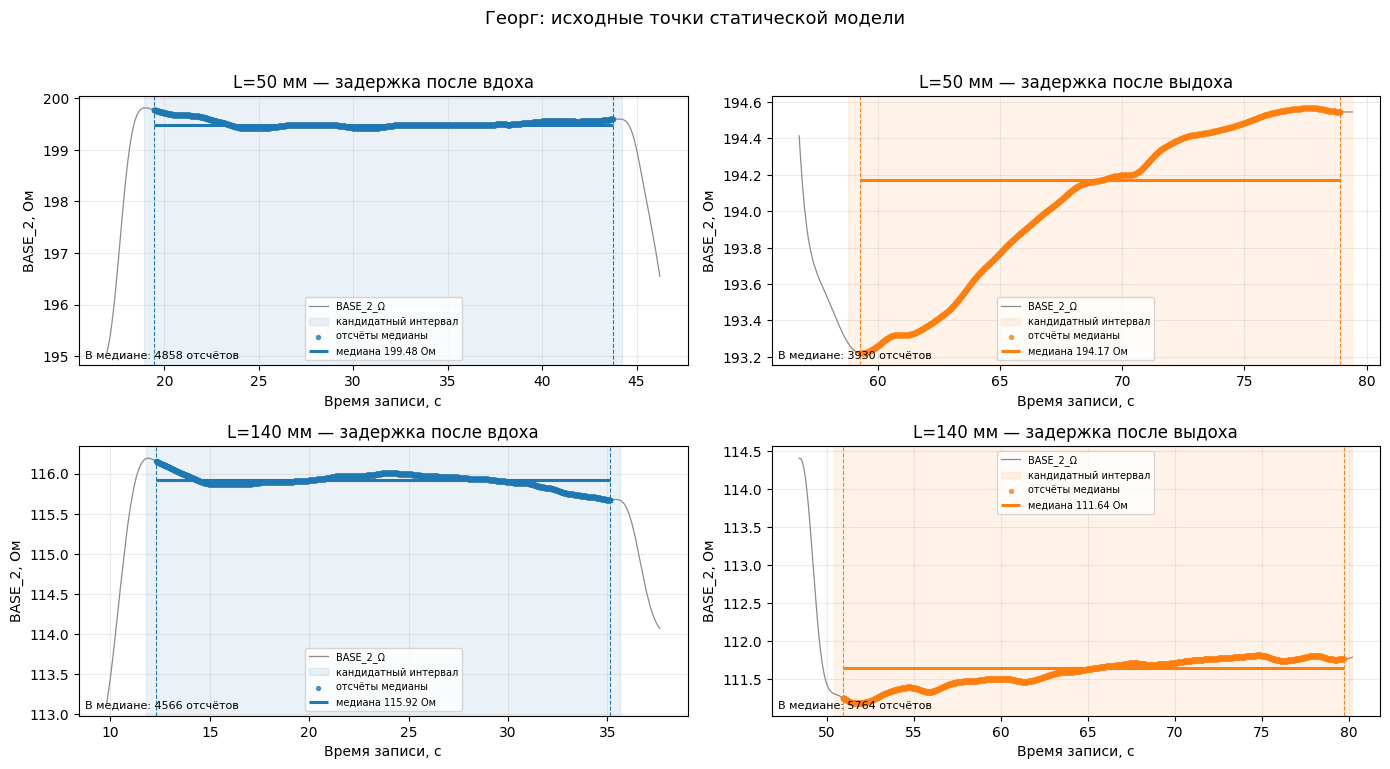

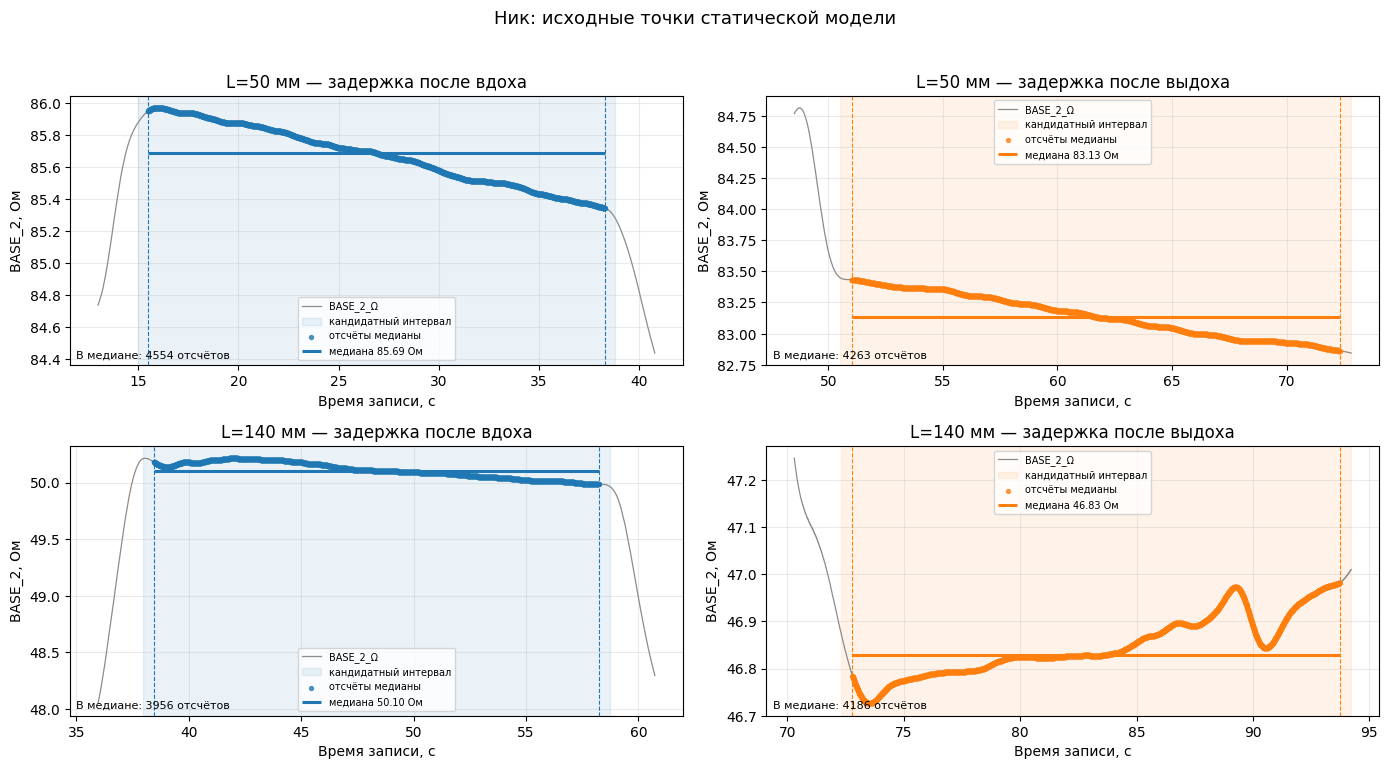

In [5]:
# Точки BASE_2, образующие статические медианы для крайних размеров
SOURCE_MARGIN_S = 0.5
SUBJECT_LABELS = {"exp02_georg": "Георг", "exp02_nik": "Ник"}
MODE_STYLE = {
    "задержка_вдох": ("задержка после вдоха", "tab:blue"),
    "задержка_выдох": ("задержка после выдоха", "tab:orange"),
}

for subject_id, subject_records in sorted(records_by_subject.items()):
    ordered = sorted(subject_records, key=lambda item: item["size_mm"])
    edge_records = [ordered[0], ordered[-1]]
    fig, axes = plt.subplots(2, 2, figsize=(14, 7.8), squeeze=False)

    for row_index, record in enumerate(edge_records):
        time_s = np.asarray(record["time_s"], dtype=float)
        base_2 = np.asarray(record["base_2_ohm"], dtype=float)
        for column_index, mode_name in enumerate(HOLD_MODES):
            axis = axes[row_index, column_index]
            mode_label, color = MODE_STYLE[mode_name]
            interval_left, interval_right = map(float, record["modes"][mode_name])
            used_left = interval_left + SOURCE_MARGIN_S
            used_right = interval_right - SOURCE_MARGIN_S
            window = (time_s >= interval_left - 2.0) & (time_s <= interval_right + 2.0)
            used = (time_s >= used_left) & (time_s <= used_right)
            median_ohm = interval_median(
                time_s,
                base_2,
                record["modes"][mode_name],
                margin_s=SOURCE_MARGIN_S,
            )

            axis.plot(time_s[window], base_2[window], color="0.55", lw=0.9,
                      label="BASE_2_Ω")
            axis.axvspan(interval_left, interval_right, color=color, alpha=0.09,
                         label="кандидатный интервал")
            axis.scatter(time_s[used], base_2[used], s=8, color=color, alpha=0.75,
                         label="отсчёты медианы", zorder=3)
            axis.hlines(median_ohm, used_left, used_right, color=color, lw=2.2,
                        label=f"медиана {median_ohm:.2f} Ом", zorder=4)
            axis.axvline(used_left, color=color, lw=0.8, ls="--")
            axis.axvline(used_right, color=color, lw=0.8, ls="--")
            axis.set_title(f"L={record['size_mm']} мм — {mode_label}")
            axis.set_xlabel("Время записи, с")
            axis.set_ylabel("BASE_2, Ом")
            axis.grid(True, alpha=0.25)
            axis.legend(fontsize=7, loc="best")
            axis.text(
                0.01,
                0.02,
                f"В медиане: {int(used.sum())} отсчётов",
                transform=axis.transAxes,
                fontsize=8,
                va="bottom",
            )

    fig.suptitle(
        f"{SUBJECT_LABELS.get(subject_id, subject_id)}: исходные точки статической модели",
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


## 9. Анализ чувствительности и практической определимости

Граничный минимум не позволяет использовать обычную локальную стандартную
ошибку для $h$. Поэтому рассматриваются профиль целевой функции и локальная
чувствительность модели.

Компенсацией параметров здесь называется их математическая
взаимозаменяемость: увеличение $h$ сопровождается таким изменением $\rho_1$
и $\rho_2$, при котором рассчитанные импедансы меняются мало. Это не поправка,
внесённая в измерения, и не предполагаемое физиологическое изменение тканей.
В пространстве параметров близкие по качеству решения образуют вытянутую
область малой ошибки. Последовательность её наиболее низких точек называется
гребнем компенсации. Если ошибка вдоль гребня меняется слабо, данные не
позволяют выбрать одну из расположенных на нём комбинаций параметров.

Профиль и локальная чувствительность описывают эту компенсацию на разных
масштабах:

- положение минимума на границе — глобальное направление улучшения подгонки;
- пологий профиль — слабое изменение целевой функции вдоль этого направления;
- близость столбцов якобиана — локальное дифференциальное описание того же
  гребня компенсации.

Следовательно, три признака согласованы, но не являются тремя независимыми
доказательствами.

### 9.1. Сходство влияния параметров

Для каждого значения $h$ строится логарифмический якобиан

$$
J_{kj}=\frac{\partial Z_k}{\partial\ln\theta_j},
$$

где $J_{kj}$ — чувствительность рассчитанного импеданса наблюдения $k$ к
логарифму параметра $j$; $Z_k$ — рассчитанный импеданс наблюдения $k$, Ом;
$\theta=(\rho_1,\rho_{2,\mathrm{in}},\rho_{2,\mathrm{ex}},h)$ — вектор
параметров; $k$ и $j$ нумеруют наблюдения и параметры соответственно. Два
параметра
трудно разделить, если соответствующие столбцы якобиана направлены почти
одинаково.

Модуль косинуса между столбцами $J_p$ и $J_q$ вычисляется как

$$
c_{pq}=\frac{|J_p^{\mathsf T}J_q|}{\lVert J_p\rVert\,\lVert J_q\rVert},
$$

где $c_{pq}$ — модуль косинуса между направлениями чувствительности; $J_p$ и
$J_q$ — столбцы якобиана для параметров $p$ и $q$. Значение $c_{pq}$, близкое
к 1, означает почти одинаковое влияние двух
параметров на набор наблюдений. Число обусловленности характеризует усиление
малых возмущений при локальном решении обратной задачи. Эти величины являются
диагностикой модели, а не доверительными интервалами.

Дополнительно направление изменения $h$ сравнивается с направлениями
изменения отношения $b/a$ и постоянного приборного смещения. Для этих факторов
пока нет экспериментально обоснованных диапазонов, поэтому оценивается только
сходство направлений, но не соответствующая погрешность $h$.

### 9.2. Фиксация удельного сопротивления верхнего слоя

Для явного отображения компенсации между $h$ и $\rho_1$ расчёт повторяется
при фиксированных значениях $\rho_1=0{,}5; 1; 2; 5; 10; 15$ Ом·м.

Для каждого $h$ заново подбираются только $\rho_{2,\mathrm{in}}$ и
$\rho_{2,\mathrm{ex}}$. Эта сетка покрывает расчётный гребень решений, но не
задаёт физиологический диапазон $\rho_1$ и не является моделью его
неопределённости.

### 9.3. Масштаб, смещение и геометрия

Общий положительный коэффициент масштаба не изменяет положение минимума $h$ в
идеальной неограниченной модели: масштабирование всех наблюдений
компенсируется таким же масштабированием удельных сопротивлений. Это свойство
нарушается, если коэффициент различается между записями или параметры
достигают заданных границ.

Если все линейные размеры сборки умножены на общий коэффициент $c$, то в
пределах модели оценки $h$ и $\rho$ также масштабируются на $c$. Поэтому общая
относительная ошибка масштаба геометрии переносится в $h$ в отношении 1:1.

Постоянное аддитивное смещение такой инвариантностью не обладает: одна и та же
добавка по-разному изменяет относительные уровни малых и больших сборок.
Численное влияние смещения на $h$ можно оценить только после задания его
допустимого диапазона.

### 9.4. Две сборки и пересечение решений

При известной $h$ одна сборка в одном дыхательном состоянии задаёт кривую
допустимых пар $(\rho_1,\rho_2)$. Две достаточно различающиеся сборки могут
дать отдельную точку пересечения. Если $h$ также неизвестна, два измерения
одного состояния задают непрерывное множество решений в пространстве
$(\rho_1,\rho_2,h)$.

Два размера и два дыхательных состояния при общих $h$ и $\rho_1$ формально
дают четыре уравнения для четырёх неизвестных. Такая система не имеет
избыточности и особенно чувствительна к несопоставимости последовательных
записей. Поэтому пару сборок следует выбирать по критерию чувствительности, а
остальные размеры сохранять для независимой проверки выбранного решения.


### 9.5. Как читать трёхпанельный рисунок чувствительности

Левая панель показывает не изменение тканей при изменении $h$, а параметры,
которые оптимизатор заново подбирает для каждого фиксированного $h$.
Значительное перемещение этих кривых при почти неизменном RMS указывает на
гребень взаимозаменяемых решений.

На средней панели используются две вертикальные оси. Фиолетовая кривая и левая
ось показывают число обусловленности: чем оно больше, тем сильнее малое
возмущение данных может изменить оценку параметров. Оранжевая кривая и правая
ось показывают модуль косинуса между влияниями $h$ и $\rho_1$. Значение,
близкое к 1, означает, что модель реагирует на эти параметры почти одинаково.

На правой панели $\rho_1$ последовательно фиксируется на разных уровнях, а
$h$ и два значения $\rho_2$ подбираются заново. Подпись `RMS×1,00` означает,
что ошибка почти совпадает с ошибкой свободной подгонки; `RMS×2,00` означает
двукратное ухудшение. Если $h$ существенно перемещается при подписях, близких
к `RMS×1,00`, выбор толщины зависит от принятого $\rho_1$ и не определяется
самими данными.


Данные анализа чувствительности сохранены во внешнем каталоге производных результатов.


,Доброволец,"h, мм","ρ1, Ом·м","ρ2, вдох, Ом·м","ρ2, выдох, Ом·м","RMS, Ом",Число обусловленности,"|cos(h, ρ1)|","|cos(h, ρ2 вдох)|","|cos(h, ρ2 выдох)|","|cos(h, b/a)|","|cos(h, смещение)|",Достигнута граница
0,Георг,1,1.0071,27.7240,26.1703,7.6743,22831.3060,1.0000,0.6866,0.6477,0.9798,0.9406,нет
1,Георг,5,4.8351,28.1104,26.4548,7.7354,408.3163,0.9999,0.6858,0.6447,0.9824,0.9442,нет
2,Георг,15,10.0796,37.6868,34.0624,9.3648,44.0188,0.9754,0.7119,0.6502,0.9905,0.9926,нет
3,Георг,20,11.0226,51.5130,44.4319,10.3862,67.6920,0.9522,0.7243,0.6535,0.9642,0.9965,нет
4,Георг,40,12.9490,1000.0000,1000.0000,14.1168,2903.0295,0.8708,0.7017,0.7017,0.8473,0.9553,да
5,Ник,1,0.4832,12.6337,11.4444,6.1028,17282.0620,1.0000,0.6979,0.6302,0.9773,0.9320,нет
6,Ник,5,2.3078,12.8426,11.5623,6.1519,348.7577,0.9999,0.6979,0.6255,0.9802,0.9361,нет
7,Ник,15,4.7486,17.1232,14.2734,7.2274,41.2997,0.9725,0.7348,0.6174,0.9887,0.9883,нет
8,Ник,20,5.1870,22.8734,17.5560,7.7703,62.2599,0.9456,0.7535,0.6144,0.9598,0.9927,нет
9,Ник,40,5.9864,1000.0000,107.0547,9.1927,4615.1488,0.8550,0.7539,0.6447,0.8322,0.9482,да


,Доброволец,"Фиксированное ρ1, Ом·м","h минимума, мм","ρ2, вдох, Ом·м","ρ2, выдох, Ом·м","RMS, Ом",RMS относительно свободного профиля,h на границе,Параметр на границе
0,Георг,0.5,1.0,144.7430,115.1225,23.7902,3.1000,да,нет
1,Георг,1.0,1.0,27.9032,26.3306,7.6765,1.0003,да,нет
2,Георг,2.0,2.0,27.8189,26.2479,7.6795,1.0007,нет,нет
3,Георг,5.0,5.0,27.2000,25.6399,7.7970,1.0160,нет,нет
4,Георг,10.0,14.0,34.5183,31.4742,9.2017,1.1990,нет,нет
5,Георг,15.0,54.0,1000.0000,173.3406,21.9971,2.8663,нет,да
6,Ник,0.5,1.0,12.2696,11.1448,6.1178,1.0025,да,нет
7,Ник,1.0,2.0,12.2283,11.1044,6.1276,1.0041,нет,нет
8,Ник,2.0,4.0,12.0587,10.9382,6.1837,1.0133,нет,нет
9,Ник,5.0,15.0,15.2924,12.8825,7.3600,1.2060,нет,нет


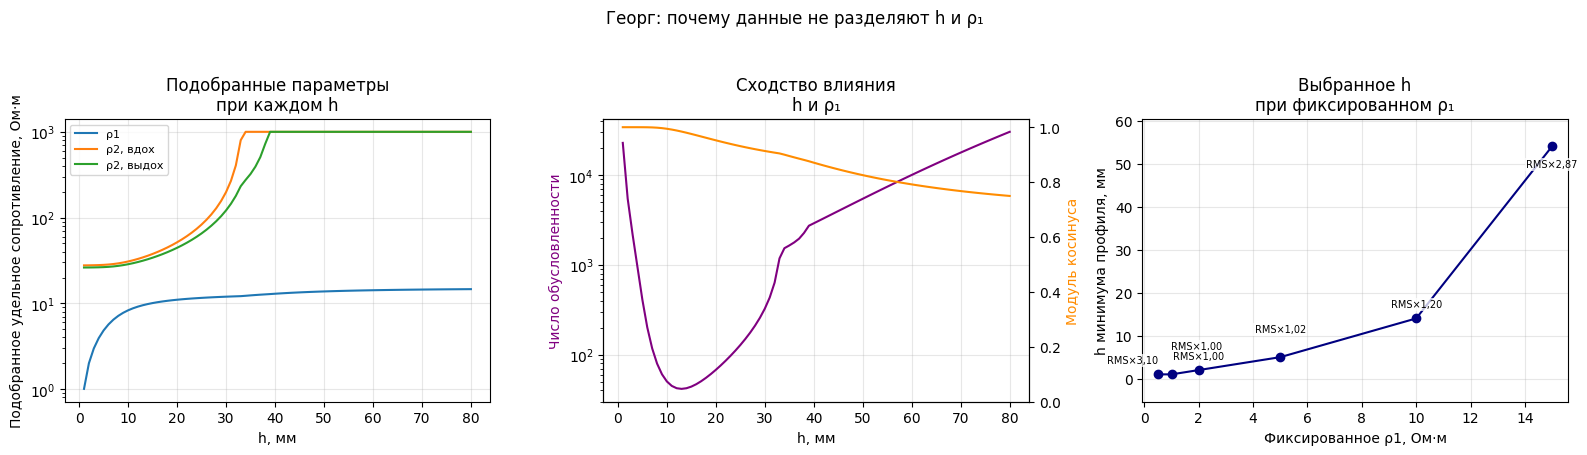

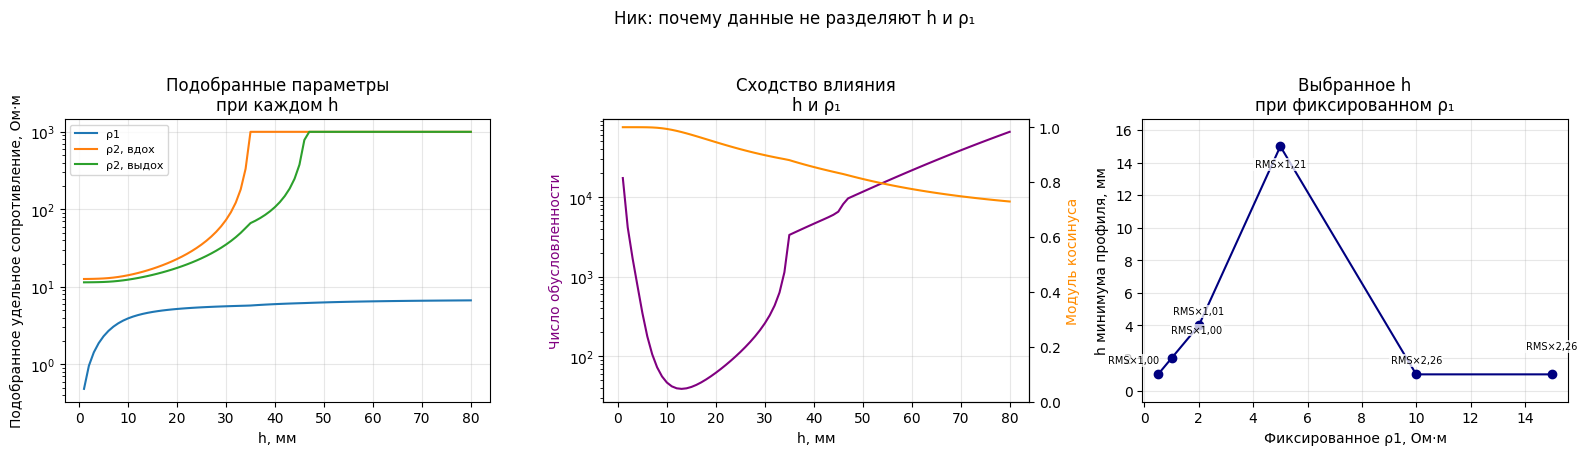

In [6]:
# Количественная диагностика чувствительности h
from scipy.optimize import least_squares
from two_layer_model import evaluate, geometry_from_size

SENSITIVITY_PATH = OUT_DIR / "33.06_h_sensitivity_exploratory.json"
FIXED_RHO1_GRID = np.asarray([0.5, 1.0, 2.0, 5.0, 10.0, 15.0], dtype=float)
SELECTED_H_MM = {1, 5, 15, 20, 40}
SUBJECT_LABELS = {"exp02_georg": "Георг", "exp02_nik": "Ник"}

base_artifact = json.loads(OUT_PATH.read_text(encoding="utf-8"))


def absolute_cosine(first, second):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    denominator = np.linalg.norm(first) * np.linalg.norm(second)
    if denominator == 0:
        return np.nan
    return float(abs(np.dot(first, second) / denominator))


def full_log_jacobian(sizes_mm, row):
    rows = []
    beta_column = []
    offset_column = []
    for size_mm in np.asarray(sizes_mm, dtype=float):
        a, b = geometry_from_size(size_mm / 1000.0)
        inhale = evaluate(
            row["rho1_ohm_m"], row["rho2_inhale_ohm_m"], row["h_m"], a, b
        )
        exhale = evaluate(
            row["rho1_ohm_m"], row["rho2_exhale_ohm_m"], row["h_m"], a, b
        )
        rows.extend([
            [
                inhale.d_rho1 * row["rho1_ohm_m"],
                inhale.d_rho2 * row["rho2_inhale_ohm_m"],
                0.0,
                inhale.d_h * row["h_m"],
            ],
            [
                exhale.d_rho1 * row["rho1_ohm_m"],
                0.0,
                exhale.d_rho2 * row["rho2_exhale_ohm_m"],
                exhale.d_h * row["h_m"],
            ],
        ])
        beta_column.extend([inhale.d_b * b, exhale.d_b * b])
        offset_column.extend([1.0, 1.0])
    return np.asarray(rows), np.asarray(beta_column), np.asarray(offset_column)


def jacobian_metrics(sizes_mm, row):
    jacobian, beta_column, offset_column = full_log_jacobian(sizes_mm, row)
    singular_values = np.linalg.svd(jacobian, compute_uv=False)
    condition = (
        float(singular_values[0] / singular_values[-1])
        if singular_values[-1] > 0 else float("inf")
    )
    h_column = jacobian[:, 3]
    return {
        "full_log_condition": condition,
        "full_log_rank": int(np.linalg.matrix_rank(jacobian)),
        "abs_cos_h_rho1": absolute_cosine(h_column, jacobian[:, 0]),
        "abs_cos_h_rho2_inhale": absolute_cosine(h_column, jacobian[:, 1]),
        "abs_cos_h_rho2_exhale": absolute_cosine(h_column, jacobian[:, 2]),
        "abs_cos_h_beta": absolute_cosine(h_column, beta_column),
        "abs_cos_h_offset": absolute_cosine(h_column, offset_column),
        "relative_h_column_norm": float(
            np.linalg.norm(h_column)
            / np.linalg.norm(
                np.ravel(np.column_stack([
                    row["predicted_inhale_ohm"],
                    row["predicted_exhale_ohm"],
                ]))
            )
        ),
    }


def fit_one_rho2(sizes_m, observed, rho1, h_m, previous=None):
    lower, upper = np.log(0.01), np.log(1000.0)

    def residual(theta):
        rho2 = float(np.exp(theta[0]))
        predicted = []
        for size_m in sizes_m:
            a, b = geometry_from_size(float(size_m))
            try:
                predicted.append(evaluate(rho1, rho2, h_m, a, b).z)
            except RuntimeError:
                return np.full_like(observed, 1.0e9)
        return np.asarray(predicted) - observed

    if previous is None:
        seeds = np.log([0.1, 1.0, 10.0, 100.0, 500.0])
    else:
        seeds = np.asarray([np.log(previous)])
    candidates = [
        least_squares(
            residual,
            np.asarray([seed]),
            bounds=(np.asarray([lower]), np.asarray([upper])),
            method="trf",
        )
        for seed in seeds
    ]
    solution = min(candidates, key=lambda item: float(np.sum(item.fun ** 2)))
    rho2 = float(np.exp(solution.x[0]))
    return {
        "rho2_ohm_m": rho2,
        "rss_ohm2": float(np.sum(solution.fun ** 2)),
        "bound_hit": bool(
            np.isclose(solution.x[0], lower, atol=1e-5)
            or np.isclose(solution.x[0], upper, atol=1e-5)
        ),
        "success": bool(solution.success),
    }


def fixed_rho1_profile(subject, fixed_rho1):
    sizes_m = np.asarray(subject["sizes_mm"], dtype=float) / 1000.0
    inhale = np.asarray(subject["observed_z_inhale_ohm"], dtype=float)
    exhale = np.asarray(subject["observed_z_exhale_ohm"], dtype=float)
    h_grid_m = np.asarray(base_artifact["scenario"]["h_grid_mm"], dtype=float) / 1000.0
    rows = []
    previous_inhale = None
    previous_exhale = None
    for h_m in h_grid_m:
        fit_inhale = fit_one_rho2(
            sizes_m, inhale, fixed_rho1, float(h_m), previous_inhale
        )
        fit_exhale = fit_one_rho2(
            sizes_m, exhale, fixed_rho1, float(h_m), previous_exhale
        )
        previous_inhale = fit_inhale["rho2_ohm_m"]
        previous_exhale = fit_exhale["rho2_ohm_m"]
        rss = fit_inhale["rss_ohm2"] + fit_exhale["rss_ohm2"]
        rows.append({
            "h_m": float(h_m),
            "rho2_inhale_ohm_m": fit_inhale["rho2_ohm_m"],
            "rho2_exhale_ohm_m": fit_exhale["rho2_ohm_m"],
            "residual_sum_squares_ohm2": float(rss),
            "residual_rms_ohm": float(np.sqrt(rss / (2 * len(sizes_m)))),
            "parameter_bound_hit": bool(
                fit_inhale["bound_hit"] or fit_exhale["bound_hit"]
            ),
            "optimizer_success": bool(
                fit_inhale["success"] and fit_exhale["success"]
            ),
        })
    best_index = int(np.argmin([row["residual_sum_squares_ohm2"] for row in rows]))
    return {"profile": rows, "best_index": best_index, "best": rows[best_index]}


all_metrics = {}
selected_metric_rows = []
fixed_results = {}
fixed_summary_rows = []

for subject_id, subject in base_artifact["subjects"].items():
    profile = subject["static_h_profile"]["profile"]
    subject_metrics = []
    for row in profile:
        metrics = jacobian_metrics(subject["sizes_mm"], row)
        combined = {"h_m": row["h_m"], **metrics}
        subject_metrics.append(combined)
        h_mm = int(round(1000.0 * row["h_m"]))
        if h_mm in SELECTED_H_MM:
            selected_metric_rows.append({
                "subject_id": subject_id,
                "h_mm": h_mm,
                "rho1_ohm_m": row["rho1_ohm_m"],
                "rho2_inhale_ohm_m": row["rho2_inhale_ohm_m"],
                "rho2_exhale_ohm_m": row["rho2_exhale_ohm_m"],
                "RMS_ohm": row["residual_rms_ohm"],
                "parameter_bound_hit": row["parameter_bound_hit"],
                **metrics,
            })
    all_metrics[subject_id] = subject_metrics

    free_best_rms = float(subject["static_h_profile"]["best"]["residual_rms_ohm"])
    fixed_results[subject_id] = {}
    for fixed_rho1 in FIXED_RHO1_GRID:
        result = fixed_rho1_profile(subject, float(fixed_rho1))
        fixed_results[subject_id][str(float(fixed_rho1))] = result
        best = result["best"]
        fixed_summary_rows.append({
            "subject_id": subject_id,
            "fixed_rho1_ohm_m": float(fixed_rho1),
            "best_h_mm": 1000.0 * best["h_m"],
            "best_rho2_inhale_ohm_m": best["rho2_inhale_ohm_m"],
            "best_rho2_exhale_ohm_m": best["rho2_exhale_ohm_m"],
            "RMS_ohm": best["residual_rms_ohm"],
            "RMS_ratio_to_free_profile": best["residual_rms_ohm"] / free_best_rms,
            "boundary_h": bool(
                np.isclose(best["h_m"], H_GRID_M.min())
                or np.isclose(best["h_m"], H_GRID_M.max())
            ),
            "parameter_bound_hit": best["parameter_bound_hit"],
        })

sensitivity_artifact = {
    "schema_version": 1,
    "status": EXPLORATORY_STATUS,
    "artifact_id": "33.06_h_sensitivity_exploratory",
    "source_artifact": OUT_PATH.name,
    "fixed_rho1_grid_ohm_m": FIXED_RHO1_GRID.tolist(),
    "interpretation": {
        "fixed_rho1_grid_is_computational_not_physiological": True,
        "boundary_h_has_no_standard_local_uncertainty": True,
        "common_gain_leaves_h_argmin_invariant_without_bounds": True,
        "common_geometry_scale_transfers_one_to_one_to_h": True,
        "offset_and_beta_require_external_uncertainty_ranges": True,
    },
    "full_jacobian_metrics": all_metrics,
    "fixed_rho1_profiles": fixed_results,
}
SENSITIVITY_PATH.write_text(
    json.dumps(json_ready(sensitivity_artifact), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

metric_table = pd.DataFrame(selected_metric_rows).rename(columns={
    "subject_id": "доброволец",
    "h_mm": "h_мм",
    "rho1_ohm_m": "rho1_Ом_м",
    "rho2_inhale_ohm_m": "rho2_вдох_Ом_м",
    "rho2_exhale_ohm_m": "rho2_выдох_Ом_м",
    "full_log_condition": "cond_4парам",
    "abs_cos_h_rho1": "abs_cos_h_rho1",
    "abs_cos_h_beta": "abs_cos_h_beta",
    "abs_cos_h_offset": "abs_cos_h_offset",
})
fixed_table = pd.DataFrame(fixed_summary_rows).rename(columns={
    "subject_id": "доброволец",
    "fixed_rho1_ohm_m": "фикс_rho1_Ом_м",
    "best_h_mm": "h_минимума_мм",
    "best_rho2_inhale_ohm_m": "rho2_вдох_Ом_м",
    "best_rho2_exhale_ohm_m": "rho2_выдох_Ом_м",
    "RMS_ratio_to_free_profile": "RMS_к_свободному",
    "boundary_h": "h_на_границе",
})

print("Данные анализа чувствительности сохранены во внешнем каталоге производных результатов.")
metric_display = metric_table[[
    "доброволец", "h_мм", "rho1_Ом_м", "rho2_вдох_Ом_м",
    "rho2_выдох_Ом_м", "RMS_ohm", "cond_4парам", "abs_cos_h_rho1",
    "abs_cos_h_rho2_inhale", "abs_cos_h_rho2_exhale",
    "abs_cos_h_beta", "abs_cos_h_offset", "parameter_bound_hit",
]].copy()
metric_display["доброволец"] = metric_display["доброволец"].replace(SUBJECT_LABELS)
metric_display = metric_display.rename(columns={
    "доброволец": "Доброволец",
    "h_мм": "h, мм",
    "rho1_Ом_м": "ρ1, Ом·м",
    "rho2_вдох_Ом_м": "ρ2, вдох, Ом·м",
    "rho2_выдох_Ом_м": "ρ2, выдох, Ом·м",
    "RMS_ohm": "RMS, Ом",
    "cond_4парам": "Число обусловленности",
    "abs_cos_h_rho1": "|cos(h, ρ1)|",
    "abs_cos_h_rho2_inhale": "|cos(h, ρ2 вдох)|",
    "abs_cos_h_rho2_exhale": "|cos(h, ρ2 выдох)|",
    "abs_cos_h_beta": "|cos(h, b/a)|",
    "abs_cos_h_offset": "|cos(h, смещение)|",
    "parameter_bound_hit": "Достигнута граница",
})
metric_display["Достигнута граница"] = metric_display["Достигнута граница"].map(
    {True: "да", False: "нет"}
)
display(metric_display.round(4))

fixed_display = fixed_table[[
    "доброволец", "фикс_rho1_Ом_м", "h_минимума_мм",
    "rho2_вдох_Ом_м", "rho2_выдох_Ом_м", "RMS_ohm",
    "RMS_к_свободному", "h_на_границе", "parameter_bound_hit",
]].copy()
fixed_display["доброволец"] = fixed_display["доброволец"].replace(SUBJECT_LABELS)
fixed_display = fixed_display.rename(columns={
    "доброволец": "Доброволец",
    "фикс_rho1_Ом_м": "Фиксированное ρ1, Ом·м",
    "h_минимума_мм": "h минимума, мм",
    "rho2_вдох_Ом_м": "ρ2, вдох, Ом·м",
    "rho2_выдох_Ом_м": "ρ2, выдох, Ом·м",
    "RMS_ohm": "RMS, Ом",
    "RMS_к_свободному": "RMS относительно свободного профиля",
    "h_на_границе": "h на границе",
    "parameter_bound_hit": "Параметр на границе",
})
for column in ("h на границе", "Параметр на границе"):
    fixed_display[column] = fixed_display[column].map({True: "да", False: "нет"})
display(fixed_display.round(4))

for subject_id, subject in base_artifact["subjects"].items():
    profile = subject["static_h_profile"]["profile"]
    metrics = all_metrics[subject_id]
    h_mm = np.asarray([1000.0 * row["h_m"] for row in profile])
    rho1 = np.asarray([row["rho1_ohm_m"] for row in profile])
    rho2_in = np.asarray([row["rho2_inhale_ohm_m"] for row in profile])
    rho2_ex = np.asarray([row["rho2_exhale_ohm_m"] for row in profile])
    condition = np.asarray([row["full_log_condition"] for row in metrics])
    cosine = np.asarray([row["abs_cos_h_rho1"] for row in metrics])
    fixed_subject = fixed_table[fixed_table["доброволец"] == subject_id]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    axes[0].semilogy(h_mm, rho1, label="ρ1")
    axes[0].semilogy(h_mm, rho2_in, label="ρ2, вдох")
    axes[0].semilogy(h_mm, rho2_ex, label="ρ2, выдох")
    axes[0].set_xlabel("h, мм")
    axes[0].set_ylabel("Подобранное удельное сопротивление, Ом·м")
    axes[0].set_title("Подобранные параметры\nпри каждом h")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].semilogy(h_mm, condition, color="purple", label="число обусловленности")
    cosine_axis = axes[1].twinx()
    cosine_axis.plot(h_mm, cosine, color="darkorange", label="|cos(h, ρ1)|")
    axes[1].set_xlabel("h, мм")
    axes[1].set_ylabel("Число обусловленности", color="purple")
    cosine_axis.set_ylabel("Модуль косинуса", color="darkorange")
    cosine_axis.set_ylim(0, 1.03)
    axes[1].set_title("Сходство влияния\nh и ρ₁")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(
        fixed_subject["фикс_rho1_Ом_м"],
        fixed_subject["h_минимума_мм"],
        "o-",
        color="navy",
    )
    maximum_h = float(fixed_subject["h_минимума_мм"].max())
    for point_index, (_, row) in enumerate(fixed_subject.iterrows()):
        x_value = float(row["фикс_rho1_Ом_м"])
        y_value = float(row["h_минимума_мм"])
        x_offset = -18 if point_index == 0 else (18 if point_index == 1 else 0)
        y_offset = -15 if y_value >= 0.85 * maximum_h else 8 + 10 * (point_index % 2)
        ratio_label = f"{row['RMS_к_свободному']:.2f}".replace(".", ",")
        axes[2].annotate(
            f"RMS×{ratio_label}",
            (x_value, y_value),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            ha="center",
            fontsize=7,
            bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 1},
        )
    axes[2].set_xlabel("Фиксированное ρ1, Ом·м")
    axes[2].set_ylabel("h минимума профиля, мм")
    axes[2].set_title("Выбранное h\nпри фиксированном ρ₁")
    axes[2].grid(True, alpha=0.3)
    axes[2].margins(x=0.04, y=0.12)

    fig.suptitle(f"{SUBJECT_LABELS.get(subject_id, subject_id)}: почему данные не разделяют h и ρ₁")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


## 10. Результаты анализа чувствительности

В свободном профиле при $h=1$ мм получено $\rho_1=1{,}007$ Ом·м для Георга и
$\rho_1=0{,}483$ Ом·м для Ника. Эти значения являются координатами граничного
расчётного решения и не интерпретируются как измеренные свойства мягких
тканей.

### 10.1. Локальная неразделимость параметров

При $h=1$ мм модуль косинуса между столбцами чувствительности $h$ и $\rho_1$
равен 0,99999995 для Георга и 0,99999993 для Ника. Числа обусловленности
полного четырёхпараметрического якобиана равны соответственно 22 831 и
17 282. Следовательно, в окрестности граничного решения изменения $h$ и
$\rho_1$ воздействуют на рассчитанные импедансы практически одинаково и не
могут быть устойчиво разделены.

Направление $h$ также близко к направлению изменения $b/a$: модули косинусов
равны 0,980 для Георга и 0,977 для Ника. Для постоянного приборного смещения
получены значения 0,941 и 0,932. Сходство с направлениями
$\rho_{2,\mathrm{in}}$ и $\rho_{2,\mathrm{ex}}$ меньше: 0,687 и 0,648 для
Георга; 0,698 и 0,630 для Ника. Эти результаты показывают, что изменения
геометрии, постоянного смещения и удельных сопротивлений могут заметно
изменять положение расчётного минимума по $h$.

### 10.2. Зависимость результата от фиксированного $\rho_1$

| Доброволец | Фиксированный $\rho_1$, Ом·м | $h$ минимума, мм | RMS, Ом | RMS относительно свободного профиля |
|---|---:|---:|---:|---:|
| Георг | 1 | 1 | 7,677 | 1,000 |
| Георг | 2 | 2 | 7,680 | 1,001 |
| Георг | 5 | 5 | 7,797 | 1,016 |
| Георг | 10 | 14 | 9,202 | 1,199 |
| Ник | 0,5 | 1 | 6,118 | 1,002 |
| Ник | 1 | 2 | 6,128 | 1,004 |
| Ник | 2 | 4 | 6,184 | 1,013 |
| Ник | 5 | 15 | 7,360 | 1,206 |

Для обоих добровольцев многократное изменение фиксированного $\rho_1$ лишь
слабо увеличивает RMS в части исследованного диапазона, но сдвигает минимум
$h$ в несколько раз. Например, для Ника изменение $\rho_1$ от 0,5 до 2 Ом·м
переносит минимум с 1 до 4 мм, тогда как RMS возрастает примерно на 1 %.
Следовательно, расчётная толщина существенно зависит от принятого значения
$\rho_1$.

При $\rho_1=15$ Ом·м расчёт Георга достигает верхней границы
$\rho_2=1000$ Ом·м. Для Ника при $\rho_1=10$ и 15 Ом·м минимум возвращается к
$h=1$ мм, но RMS увеличивается примерно в 2,26 раза. Эти точки характеризуют
непригодность соответствующей ветви подгонки, а не физиологическое уменьшение
толщины.

Если ряд прямой модели не сходится для пробного сочетания параметров, функции
остатка присваивается штрафной вектор большой нормы. Такая точка исключается
из выбора минимума по вычислительному критерию; это правило не имеет
самостоятельной физической интерпретации.


## 11. Ограничения вычислительного эксперимента

1. Плоская двуслойная модель не воспроизводит отдельно форму грудной клетки,
   кожу, жировую ткань, мышцы, рёбра и неоднородность лёгкого.
2. Точечная модель электродов не учитывает их площадь, контактное
   сопротивление и погрешность ручной установки.
3. Размерные записи выполнены последовательно. Изменения физиологического
   состояния, контакта и положения электродов могут смешиваться с влиянием
   размера сборки.
4. Дыхательные интервалы и R-зубцы имеют статус кандидатной разметки и требуют
   ручной проверки до физиологической интерпретации.
5. Отображение каналов в знаковый передаточный импеданс принято как сценарное
   допущение: масштаб 1, смещение 0, знак +1.
6. Невзвешенная целевая функция придаёт всем агрегированным точкам одинаковый
   вес и не использует оценки их индивидуальной неопределённости.
7. Общие $h$ и $\rho_1$ для двух дыхательных состояний являются допущением
   модели; возможное изменение толщины верхнего слоя при дыхании не учитывается.
8. Диапазоны вариации геометрии, смещения, контакта и повторной установки пока
   не заданы, поэтому полный интервал неопределённости для $h$ не строится.
9. Соответствие эффективного параметра $h$ анатомической толщине и
   индивидуальной конечноэлементной модели в этом расчёте не устанавливается.

## 12. Вывод

В принятой постановке эффективная толщина верхнего слоя $h$ не определяется
только по имеющейся размерной зависимости бокового импеданса. На это указывают
три взаимосвязанных проявления одного гребня компенсации:

- глобально целевая функция уменьшается к нижней границе сетки;
- вдоль профиля изменение RMS мало по сравнению с многократным изменением
  $h$ и $\rho_1$;
- локально столбцы якобиана для $h$ и $\rho_1$ практически коллинеарны.

Первые два признака описывают геометрию целевой функции, а третий — её
линейное приближение в выбранной точке. Их согласованность усиливает
диагностический вывод, но не превращает их в независимые подтверждения.

Результат относится к математической модели и принятому вычислительному
сценарию. Он не доказывает принципиальную невозможность оценки глубины по
электрическим измерениям. Для отделения $h$ от удельных сопротивлений и
неучтённых различий между записями требуется дополнительная информация либо
иная параметризация прямой модели.

## 13. Дальнейшие расчёты

Для основной ветви разработки целесообразны следующие действия:

1. На синтетических данных той же прямой модели проверить восстановление
   заранее заданного $h$ при контролируемых возмущениях. Такая проверка
   подтверждает корректность реализации, но не физическую адекватность модели.
2. Построить остатки отдельно для каждого размера, дыхательного состояния и
   исходной записи; проверить парную структуру остатков и устойчивость профиля
   при последовательном исключении записей.
3. Задать обоснованные диапазоны вариации геометрии, постоянного смещения,
   контакта и повторной установки и оценить их влияние на положение профиля.
4. Проверить альтернативную параметризацию тонкого верхнего слоя, например
   через комбинацию $\rho_1/h$, и определить, какая комбинация параметров
   действительно поддерживается данными.
5. После оценки устойчивости выбрать информативную пару сборок, сохранив
   остальные размеры как проверочный набор.

**Отдельный вариант дальнейшей работы, не являющийся обязательным этапом
основной ветви:** построить для добровольца модель КТ→FEM, рассчитать
синтетические импедансы на индивидуальной анатомии и затем подобрать к ним
редуцированную двуслойную модель. Такой расчёт позволил бы исследовать связь
между анатомической толщиной и эффективным параметром $h$, но не должен делать
КТ обязательным входом целевой сокращённой методики.

До выполнения соответствующих проверок параметры $h$, $\rho_1$, $\rho_2$,
$\Delta\rho_1$ и $\Delta\rho_2$ остаются условными параметрами вычислительной
двуслойной модели.
